In [1]:
%load_ext autoreload
%autoreload 2

import sys
import pathlib
from pathlib import Path
# Add the notebook's directory to the Python path
project_dir = pathlib.Path().resolve()  # vscode executes in the workspace root
notebook_dir = project_dir / 'LDH_demo'
sys.path.append(str(notebook_dir))
sys.path

['/Users/milan/.pyenv/versions/3.11.7/lib/python311.zip',
 '/Users/milan/.pyenv/versions/3.11.7/lib/python3.11',
 '/Users/milan/.pyenv/versions/3.11.7/lib/python3.11/lib-dynload',
 '',
 '/Users/milan/.local/share/virtualenvs/experiments-2XM9RiFo/lib/python3.11/site-packages',
 '/Users/milan/Code/fusion/experiments/LDH_demo']

In [2]:
from model import FNOLSTM
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from scipy.interpolate import interp1d
import os

In [3]:
# global model settings
tw = 40
offset_pred = 20
stride = 10

In [4]:
with open(notebook_dir/'train.txt', 'r') as f:
    train_shots = json.load(f)
with open(notebook_dir/'test.txt', 'r') as f:
    test_shots = json.load(f)

In [5]:
dataset_path = '/Users/milan/Code/fusion/data/LHD_labeled_TCV/'
signal_template = dataset_path + 'TCV_DATAno{shot}.parquet'
label_template = dataset_path + 'TCV_{shot}_apau_labeled.csv'

In [6]:
def check_files_exist(file_list: list):
    """
    Check if files exist in the given list.
    """
    sig_exist, lab_exist = 0, 0
    for shot in file_list:
        signal_path = signal_template.format(shot=shot)
        label_path = label_template.format(shot=shot)
        # count existence of files
        sig_exist += os.path.exists(signal_path)
        lab_exist += os.path.exists(label_path)
    print(f"Signals exist: {sig_exist}/{len(file_list)}")
    print(f"Labels exist: {lab_exist}/{len(file_list)}")

print("Checking training files...")
check_files_exist(train_shots)
print("Checking testing files...")
check_files_exist(test_shots)


Checking training files...
Signals exist: 224/238
Labels exist: 238/238
Checking testing files...
Signals exist: 36/37
Labels exist: 37/37


In [7]:
def create_input(sig, signal_list, stats):
    assert all([s in stats for s in signal_list])
    columns = []
    for s in signal_list:
        columns.append(torch.tensor((sig[s].values - stats[s]["mean"])/ stats[s]["sd"]))
    return torch.tensor(sig.time), torch.stack(columns)

In [8]:
def pred_sample_slidingwindow(model, t, x, device, tw, stride, offset_pred, i_start=0):
    model.eval()
    x = x.to(device)
    model.to(device)
    hidden = None
    t_max = x.shape[1] - tw + 1  # max index for the sliding window
    y_preds = []
    y_gts = []
    y_times = []
    for k in range(i_start, t_max, stride):
        i_s = k # start index
        i_e = k + tw # end index
        i_time = k + tw - 1 - offset_pred
        with torch.no_grad():
            y_pred, hidden = model(x[:, i_s:i_e].unsqueeze(0), hidden)
        y_times.append(t[i_time])

        y_preds.append(y_pred.squeeze(0))
    y_preds = torch.stack(y_preds).argmax(dim=1).to('cpu')
    y_times = torch.tensor(y_times, device='cpu')
    
    return y_times, y_preds

In [11]:
def predict_and_plot(shot, model, signal_list, stats, title=None, file_out=None):
    if not os.path.exists(signal_template.format(shot=shot)):
        print(f"Missing parquet for #{shot}")
        return
    if not os.path.exists(label_template.format(shot=shot)):
        print(f"Missing csv for #{shot}")
        return
    
    sig = pd.read_parquet(signal_template.format(shot=shot))
    label = pd.read_csv(label_template.format(shot=shot))
    
    t_input, sig_input = create_input(sig, signal_list, stats)
    t_out, y_out = pred_sample_slidingwindow(model, t_input, sig_input, device='cpu', tw=tw, stride=stride, offset_pred=offset_pred, i_start=0)
    
    fig, ax = plt.subplots()
    fig.set_size_inches((8, 3))
    ax.plot(sig.time, sig.PD, color='black', linewidth=.5)
    if title is not None:
        ax.set_title(title)
        

    
    LHD_valid = ~(label.LHD_label == 0)  # 0 labels make no sense, just interpolate to nearest as easy fix
    LHD_label = interp1d(label.time[LHD_valid], label.LHD_label[LHD_valid], bounds_error=False, fill_value=np.nan, kind='nearest')(label.time)
    
    ax2 = ax.twinx()
    ax2.plot(label.time, LHD_label, label='labels')
    ax2.plot(t_out, y_out + 1, linestyle='--', linewidth=2, alpha=1, label='prediction')  # labels in dataset are 1, 2, 3, model outputs are 0, 1, 2 --> adjust
    plt.legend()
    if file_out is not None:
        out_path = Path('output/mode_predictions') / file_out
        out_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(str(out_path), bbox_inches='tight')
        plt.close(fig)
        return
    plt.show()


In [12]:
#  PD model
model_PD = FNOLSTM(n_in=1, n_out=3, tw=tw,
               h_c1=32, h_c2=64, h_m1=8, h_m2=8, h_dropc=0.5, h_maxpool=2,
               h_lstm_in=32, h_lmst=32, h_mlp=8, m_dropmlp=0.5)
model_PD.load_state_dict(torch.load(notebook_dir/"models_milan/weights_PD.pt"))
with open(notebook_dir/'models_milan/stats_PD.json', 'r') as f:
    stats_PD = json.load(f)


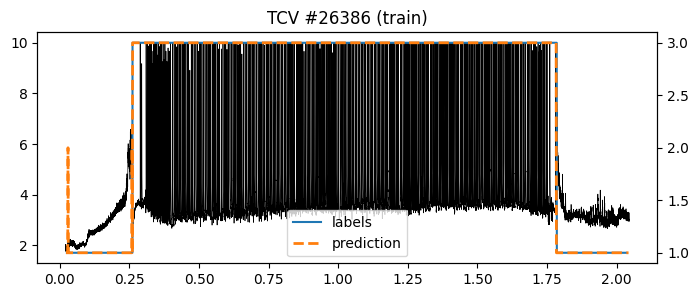

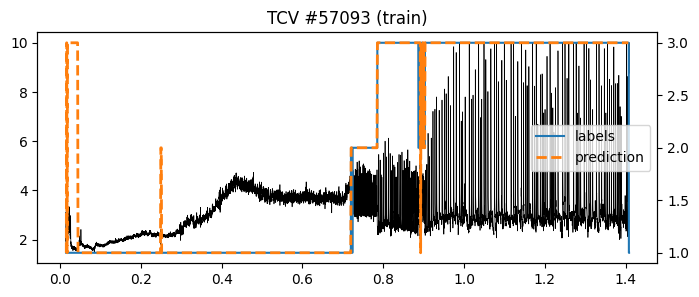

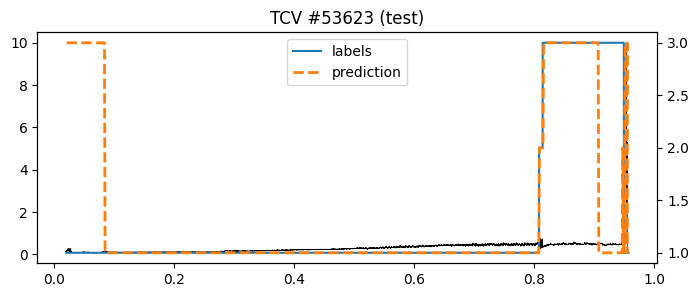

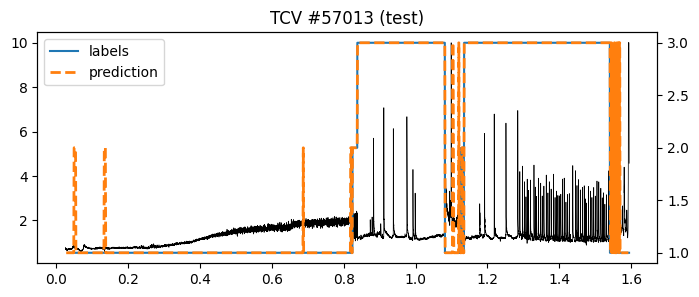

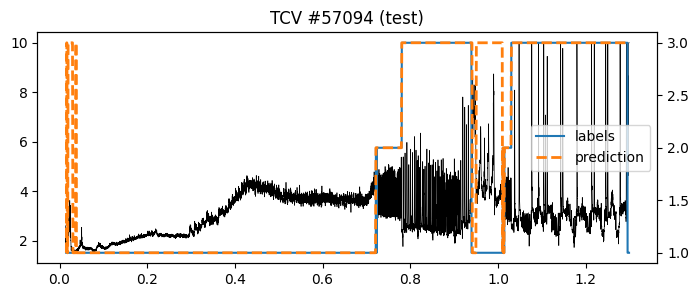

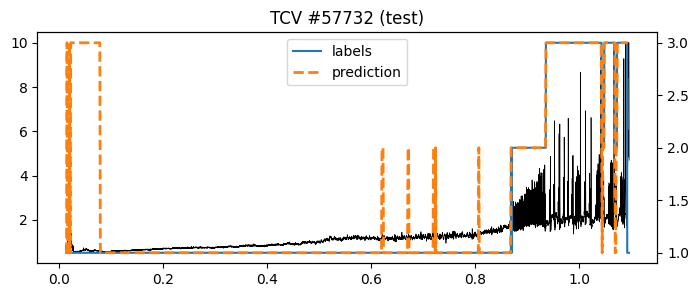

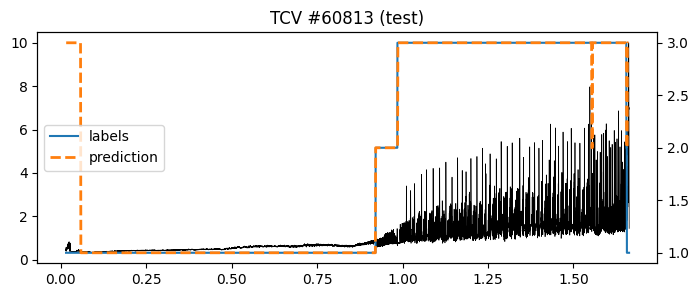

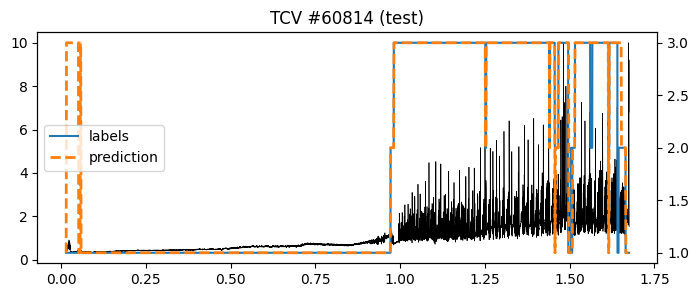

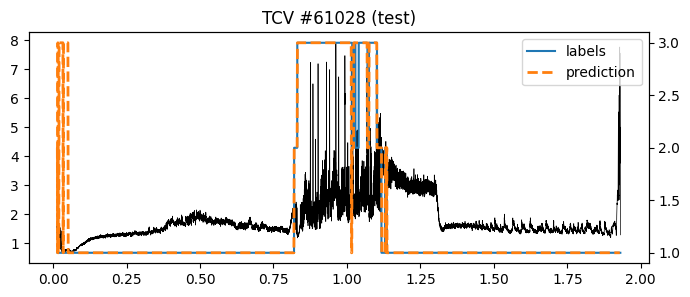

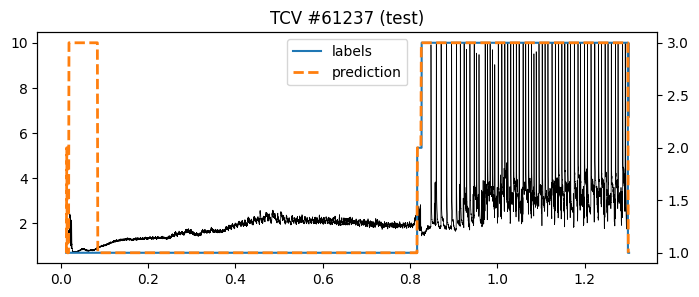

Missing parquet for #63306


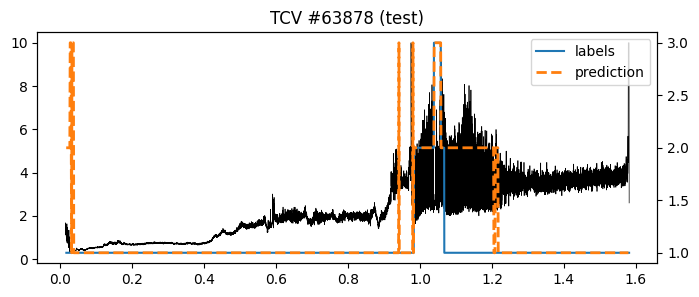

In [13]:
signal_list_PD = ["PD"]
for i in [0, 50]:
    shot = train_shots[i]
    predict_and_plot(shot, model_PD, signal_list_PD, stats_PD, title=f'TCV #{shot} (train)')
    
for i in range(10):
    
    shot = test_shots[i]
    predict_and_plot(shot, model_PD, signal_list_PD, stats_PD, title=f'TCV #{shot} (test)')

In [ ]:
signal_list_PD = ["PD"]
for shot in train_shots:
    predict_and_plot(shot, model_PD, signal_list_PD, stats_PD, title=f'TCV #{shot} (train) (PD based prediction)', file_out=f'train_{shot}_PD.jpg')

for i in range(10):

    shot = test_shots[i]
    predict_and_plot(shot, model_PD, signal_list_PD, stats_PD, title=f'TCV #{shot} (test)')

In [45]:
# all model
model_all = FNOLSTM(n_in=5, n_out=3, tw=tw,
               h_c1=32, h_c2=64, h_m1=8, h_m2=8, h_dropc=0.5, h_maxpool=2,
               h_lstm_in=32, h_lmst=32, h_mlp=8, m_dropmlp=0.5)
model_all.load_state_dict(torch.load(notebook_dir / "models_milan/weights_all.pt"))
with open(notebook_dir/'models_milan/stats_all.json', 'r') as f:
    stats_all = json.load(f)
    

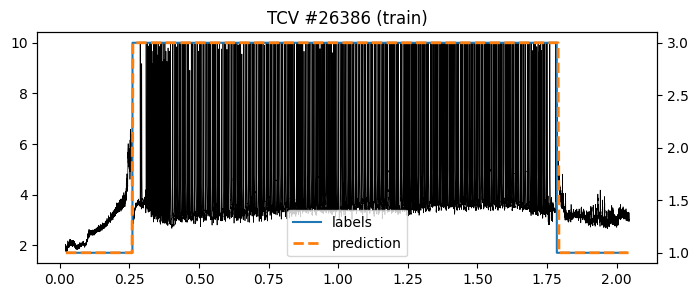

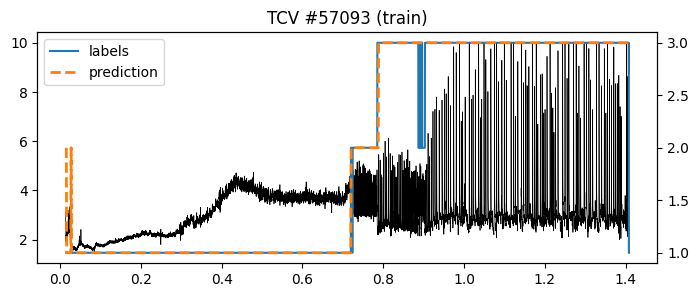

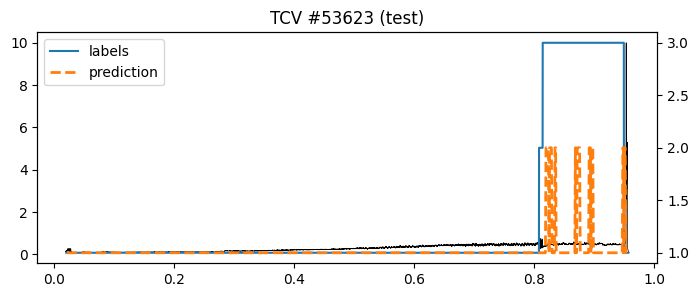

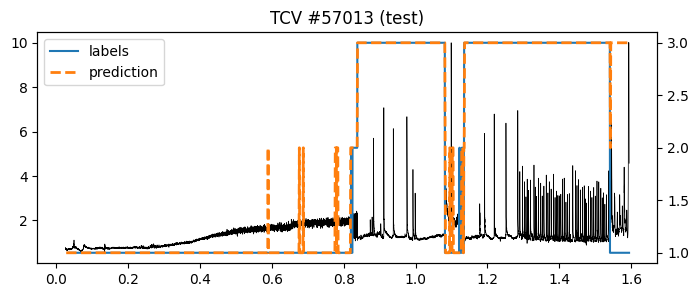

KeyboardInterrupt: 

In [63]:
signal_list_all = ["FIR_core", "PD", "DML", "POHM", "Z_axis"]
for i in [0, 50]:
    shot = train_shots[i]
    predict_and_plot(shot, model_all, signal_list_all, stats_all, title=f'TCV #{shot} (train)')
    
for i in range(5):
    shot = test_shots[i]
    predict_and_plot(shot, model_all, signal_list_all, stats_all, title=f'TCV #{shot} (test)')

In [54]:
import tqdm


In [62]:
signal_list_PD = ["PD"]
signal_list_all = ["FIR_core", "PD", "DML", "POHM", "Z_axis"]
for shot in tqdm.tqdm(train_shots):
    predict_and_plot(
        shot,
        model_PD,
        signal_list_PD,
        stats_PD,
        title=f'TCV #{shot} (train) (PD based prediction)',
        file_out=f'train_{shot}_PD.jpg'
    )
    predict_and_plot(shot, model_all, signal_list_all, stats_all, title=f'TCV #{shot} (train) (all based prediction)', file_out=f'train_{shot}_all.jpg')

for shot in tqdm.tqdm(test_shots):
    predict_and_plot(
        shot,
        model_PD,
        signal_list_PD,
        stats_PD,
        title=f'TCV #{shot} (test) (PD based prediction)',
        file_out=f'test_{shot}_PD.jpg'
    )
    predict_and_plot(shot, model_all, signal_list_all, stats_all, title=f'TCV #{shot} (test) (all based prediction)', file_out=f'test_{shot}_all.jpg')

  0%|          | 0/238 [00:00<?, ?it/s]

 47%|████▋     | 112/238 [07:47<11:59,  5.71s/it]

Missing parquet for #63230
Missing parquet for #63230
Missing parquet for #63232
Missing parquet for #63232
Missing parquet for #63234
Missing parquet for #63234


 49%|████▊     | 116/238 [07:51<05:32,  2.72s/it]

Missing parquet for #63238
Missing parquet for #63238
Missing parquet for #63240
Missing parquet for #63240
Missing parquet for #63242
Missing parquet for #63242
Missing parquet for #63244
Missing parquet for #63244
Missing parquet for #63246
Missing parquet for #63246


...

 55%|█████▌    | 131/238 [08:11<03:36,  2.02s/it]

Missing parquet for #63877
Missing parquet for #63877


 22%|██▏       | 8/37 [00:35<02:09,  4.48s/it]

Missing parquet for #63306
Missing parquet for #63306


100%|██████████| 37/37 [02:32<00:00,  4.12s/it]
